# Transverse Field Ising Model (TFIM) evolution using Pauli Propagation

In [3]:
# using Pkg; Pkg.add("PauliPropagation")
using PauliPropagation

#include("../src/pauli_propagation_functions.jl")
include("pauli_propagation_functions.jl")
import .pauli_propagation_functions as pp

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


# 1. Introduction

Before we gonna focus on a simple and controlled setting in order to validate the method and build intuition before moving to more complex circuits.

We consider a system of $n=2$ qubits arranged on a 1D chain. The quantum dynamics is generated by a circuit composed of **two-qubit gates** applied in a **bricklayer pattern**.

In [4]:
nqubits = 2

topology = bricklayertopology(nqubits; periodic=false)

1-element Vector{Tuple{Int64, Int64}}:
 (1, 2)

Each layer consists of nearest-neighbor gates of the form:

$$
U_{ij} = e^{-i \theta X_i X_j}
$$

where $X_i$ is the Pauli X operator acting on qubit $i$, and $\theta$ is a fixed parameter (Trotter step).


This type of circuit corresponds to a Trotterized time evolution under an XX Hamiltonian:

$$
H = \sum_{\langle i,j \rangle} X_i X_j
$$

In [5]:
function simple_trotter_circuit_XX(nqubits::Integer, nlayers::Integer; topology=nothing)
    circuit::Vector{Gate} = []

    if isnothing(topology)
      topology = bricklayertopology(nqubits; periodic=false)
    end

    for _ in 1:nlayers
      rxxlayer!(circuit, topology)
    end
    return circuit
end

simple_trotter_circuit_XX (generic function with 1 method)

---

## 1.1 Heisenberg picture

Instead of evolving a quantum state, we study the evolution of an observable $O$ in the Heisenberg picture:

$$
O(t) = U^\dagger O U
$$

In this notebook, we choose as initial observable a local Pauli operator:

$$
O = Z_i
$$

In [6]:
i = 1
Z_i = PauliString(nqubits, :Z, i) # I...IZI...I

observable = Z_i

PauliString(nqubits: 2, 1.0 * ZI)

---

## 1.2 Pauli propagation method

The key idea of Pauli propagation is to express the observable as a sum of Pauli strings:

$$
O = \sum_\alpha c_\alpha P_\alpha
$$

and to propagate each Pauli string through the circuit.

Under conjugation by quantum gates, Pauli strings transform into linear combinations of other Pauli strings. This leads to a growth in the number of terms, which is controlled in practice using:

- truncation of small coefficients
- limitation of the Pauli weight

This method is particularly efficient when the operator remains relatively sparse in the Pauli basis.

Here we want to verify the implementation : we don't apply truncation.

In [7]:
# the truncations
max_weight = typemax(Int)   # no limit          in the documentation they put = 6
min_abs_coeff = 0.0         # no truncations                  """             = 1e-4

0.0

We need to pay attention to the values of our truncations to avoid diverging from the exact solutions. We can verify whether our method is always implemented correctly by measuring the norm of the observable, which should be close to 1.

$$\sum_\alpha |c_\alpha|^2 = 1$$

In [8]:
# norm = pp.pauli_norm(pauli_sum)

---

## 1.3 Propagation in the TFIM Circuit

In [9]:
nlayers = 150
circuit = simple_trotter_circuit_XX(nqubits, nlayers; topology)

dt = 0.1 # time step
parameters = ones(countparameters(circuit)) * dt # parameters of all evolution gates take the same value

# propagate through the circuit
pauli_sum = propagate(circuit, observable, parameters; max_weight, min_abs_coeff)

PauliSum(nqubits: 2, 2 Pauli terms:
 0.65029 * YX
 -0.75969 * ZI
)

## 1.4 Analytucal result

We can calculate the same circuit analytically and compare our results :

In [10]:
import LinearAlgebra as la

#------- init matrix -------#
I_mat = ComplexF64[1 0;
                   0 1]

Z = ComplexF64[1  0;
               0 -1]

Y = ComplexF64[0 -1im;
               1im 0]

X = ComplexF64[0 1;
               1 0]

#------- Analytic data -------#
Z1 = kron(Z, I_mat)
H = kron(X, X)
U = exp(-1im * dt * H / 2) # U = e^{-i * dt * H /2}
U_dagger = U'

Z1_t_analytic = copy(Z1)
for _ in 1:nlayers
    global Z1_t_analytic = U_dagger * Z1_t_analytic * U # Z1(t) = U^\dagger Z1(t-dt) U
end

#------- Pauli Propagation data -------#
pauli_propagation_result = Dict(
    "5" => 0.47943 * kron(Y, X) + 0.87758 * kron(Z, I_mat),
    "150" => 0.65029 * kron(Y, X) - 0.75969 * kron(Z, I_mat)
)

Z1_t_pauli_propagation = pauli_propagation_result[string(nlayers)]

#------- result print -------#
is_close = isapprox(Z1_t_pauli_propagation, Z1_t_analytic, rtol=1e-5)
println("Is the analytical calculation close to the Pauli propagation result?  ", is_close)

error_val = la.norm(Z1_t_pauli_propagation - Z1_t_analytic)
println("with an error of :  ", error_val)

Is the analytical calculation close to the Pauli propagation result?  true
with an error of :  6.007022389552021e-6


We obtain the same result, barring a numerical error of $10^{-6}$ with $150$ evolution steps.

---

# 2. Quantities and measurements

## 2.1 Pauli Entropy

For an observable express as a sum of Pauli strings, we define the Pauli Entropy:

$$ S = - \sum_\alpha |c_\alpha|^2 log(|c_\alpha|^2)$$

In [11]:
entropy = pp.pauli_entropy(pauli_sum)

0.6812027932537481

---

## 2.2 Overlap with the intial state $|0\rangle$

$$\langle A \rangle_{\psi(t)} = \langle \psi_0 | U^\dagger A U | \psi_0\rangle = \langle \psi_0 | A(t) | \psi_0\rangle = \langle \psi_0 | \sum_k c_k(t) P_k | \psi_0\rangle$$

$$\implies \langle A \rangle_{\psi(t)} = \sum_k c_k(t) \langle \psi_0 | P_k | \psi_0\rangle$$

We know :
- $\langle 0 | I | 0 \rangle = \langle 0 | 0 \rangle = 1$
- $\langle 0 | Z | 0 \rangle = \langle 0 | 0 \rangle = 1$
- $\langle 0 | X | 0 \rangle = \langle 0 | 1 \rangle = 0$
- $\langle 0 | Y | 0 \rangle = i \langle 0 | 1 \rangle = 0$

So if the initial state $| \psi_0 \rangle = |00\dots0\rangle$ :

$$\implies \langle A \rangle_{\psi(t)} = \sum_k c_k(t) \langle 00\dots0 | P_k | 00\dots0\rangle = \sum_{\alpha} c_\alpha(t)$$

where $\forall \alpha, P_\alpha$ contains **only** the identity $I$ and the operator $Z$.

In [12]:
function decode_pauli(pauli_string, num_qubits::Int)
    mapping = Dict(0b00 => "I", 0b01 => "X", 0b10 => "Y", 0b11 => "Z")

    res = ""
    for i in 0:(num_qubits - 1)
        bits = (pauli_string >> (2 * i)) & 0b11
        res *= mapping[bits]
    end
    return res
end

function compute_overlap(observable::PauliSum)
  result = 0.0
  for (pauli_string, coeff) in observable
      string = decode_pauli(pauli_string, observable.nqubits)
      if !(contains(string, "X") || contains(string, "Y"))
          result += real(coeff)
      end
  end
  return result
end

compute_overlap (generic function with 1 method)

But in this package we have a function `overlapwithzero()` which does exactly the same thing :

In [13]:
overlap1 = compute_overlap(pauli_sum)
overlap2 = overlapwithzero(pauli_sum)

println("The two overlap are close : ", (overlap1 ≈ overlap2))

The two overlap are close : true


---

## 2.3 Propagation layer by layer

We need to see how a certain quantity behaves as it propagates through the circuit, which the `propagation()` function in the package does not allow us to do, since it only gives us the result.

In [14]:
nqubits = 10
i = 1
Z_i = PauliString(nqubits, :Z, i) # I...IZI...I

observable = Z_i

nlayers = 200

circuit = simple_trotter_circuit_XX(nqubits, nlayers; topology)
dt = 0.1 # time step
parameters = ones(countparameters(circuit)) * dt # parameters of all evolution gates take the same value

pauli_sum, result = pp.propagate_layerbylayer(circuit, observable, nlayers, parameters;
                          max_weight, min_abs_coeff)
println(pauli_sum)

pauli_sum2 = propagate(circuit, observable, parameters;
                          max_weight, min_abs_coeff)
println(pauli_sum2)

println("The two pauli sum are close : ", (pauli_sum ≈ pauli_sum2))

layer : 20/200 complete
layer : 40/200 complete
layer : 60/200 complete
layer : 80/200 complete
layer : 100/200 complete
layer : 120/200 complete
layer : 140/200 complete
layer : 160/200 complete
layer : 180/200 complete
layer : 200/200 complete
Time taken by pp.propagate_layerbylayer: 0.3153879642486572 seconds
PauliSum(nqubits: 10, 2 Pauli terms:
 0.91295 * YXIIIIIIII
 0.40808 * ZIIIIIIIII
)
PauliSum(nqubits: 10, 2 Pauli terms:
 0.91295 * YXIIIIIIII
 0.40808 * ZIIIIIIIII
)
The two pauli sum are close : true


This feature now allows us to calculate values based on the circuit layers like : entropy or overlap with the initial state.

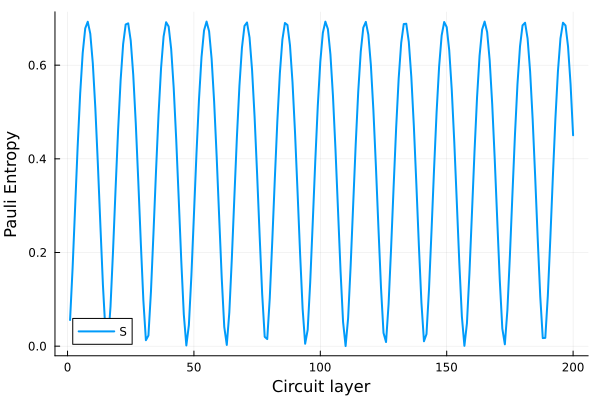

In [15]:
using Plots

entropy = result["S"]
plot(1:nlayers, entropy,
     xlabel="Circuit layer",
     ylabel="Pauli Entropy",
     label="S",
     lw=2)



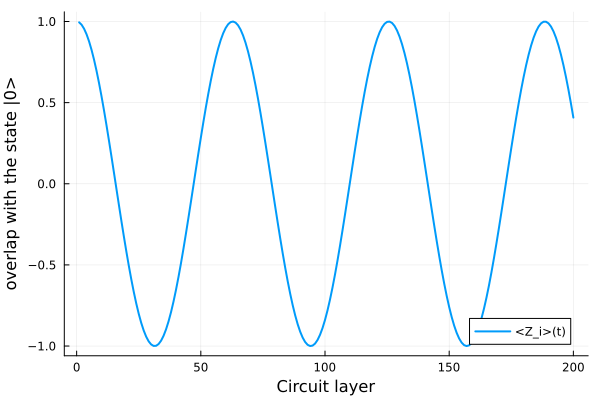

In [16]:
overlap = result["overlap"]
plot(1:nlayers, overlap,
     xlabel="Circuit layer",
     ylabel="overlap with the state |0>",
     label="<Z_i>(t)",
     lw=2)

---

## References

- https://arxiv.org/abs/2505.21606
- https://github.com/MSRudolph/PauliPropagation.jl
- [Julia documentation](https://docs.julialang.org/en/v1/)